# Excercise E3

This notebook produces the following maps:

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

## Part 1:
Mapping the Antarctic continent and the southern ocean

In [1]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

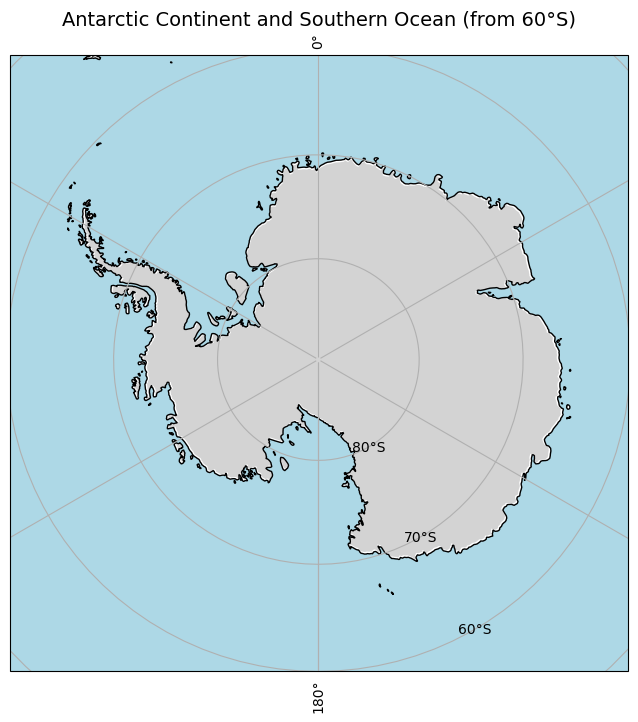

In [20]:
# -------------------------------
# 1. Antarctic continent + Southern Ocean from 60°S
# -------------------------------
fig = plt.figure(figsize=(10, 8))

ax1 = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax1.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Add features
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE)

ax1.gridlines(draw_labels=True)
ax1.set_title("Antarctic Continent and Southern Ocean (from 60°S)", fontsize=14)

plt.show()

# Part 2

Mapping the South Atlantic Ocean and coastal cities of the South Atlantic

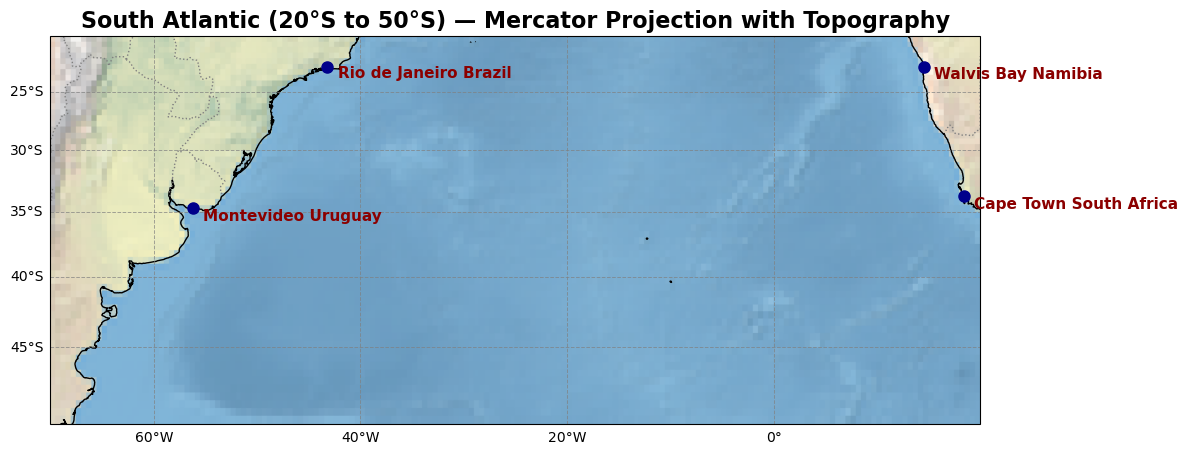

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geopy.geocoders import Nominatim

# Define the extent for the South Atlantic
extent = [-70, 20, -50, -20]

# Define places
place = ['Walvis Bay Namibia', 'Cape Town South Africa', 'Rio de Janeiro Brazil', 'Montevideo Uruguay']

# Geocode the places
geolocator = Nominatim(user_agent="cartopy_example")
address = [geolocator.geocode(p, language="en") for p in place]

# Create the map with Mercator projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add shaded relief (topography) for land
ax.stock_img()   # Natural Earth shaded relief image

# Add coastlines and borders for clarity
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="gray")

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.7, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot the places with styled markers and labels
for p in range(len(place)):
    ax.plot(address[p].longitude, address[p].latitude, 'o', color='darkblue', markersize=8, transform=ccrs.Geodetic())
    ax.text(address[p].longitude + 1, address[p].latitude - 1, place[p],
            transform=ccrs.Geodetic(), fontsize=11, fontweight='bold', color='darkred')

# Title
ax.set_title("South Atlantic (20°S to 50°S) — Mercator Projection with Topography", fontsize=16, fontweight='bold')

plt.show()